# SQLite Data Warehouse Builder

In this notebook, we will build an SQLite Data Warehouse for future SQL querying, Analytics and RAG applications.

In [265]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import json

## Data Loading and Database Setup

In [266]:
# Create database repository
db_path = Path("database")

db_path.mkdir(
    parents=True,
    exist_ok=True
)

In [267]:
# Initialize sqlite connection
conn = sqlite3.connect(
    db_path / "youtube_reviews.db"
)

In [268]:
# Display all available queries:
processed_base = Path("data/processed")

available_queries = [
    folder.name
    for folder in processed_base.iterdir()
    if folder.is_dir()
]

print(available_queries)

['alibaba_review', 'dhl_logistik_experiences_erfahrungen', 'etsy_experiences', 'zalando_review']


In [269]:
# Select query_slug from available options as before:

query_slug = "etsy_experiences"

processed_path = (
    Path("data/processed")
    / query_slug
)

In [270]:
# Load processed data from previous pipeline step: 

videos_df = pd.read_csv(
    processed_path / "videos_clean.csv"
)

comments_df = pd.read_csv(
    processed_path / "comments_clean.csv"
)

## Avoid adding duplicates from the same query to the database again

### For Videos:

In [271]:
# Load a list of existing video IDs from the database:
existing_videos = pd.read_sql(
    """
    SELECT video_id, query_slug
    FROM videos
    """,
    conn
)

# Left merge with videos Dataframe:
videos_to_insert = videos_df.merge(
    existing_videos,
    on=["video_id", "query_slug"],
    how="left",
    indicator=True
)

# Keep only new ones:
videos_to_insert = videos_to_insert[
    videos_to_insert["_merge"] == "left_only"
]

# Drop helper column:
videos_to_insert = videos_to_insert.drop(
    columns="_merge"
)

### For Comments:

In [272]:
# Load a list of existing comment IDs from the database:
existing_comments = pd.read_sql(
    """
    SELECT comment_id, query_slug
    FROM comments
    """,
    conn
)

# Left merge with comments Dataframe:
comments_to_insert = comments_df.merge(
    existing_comments,
    on=["comment_id", "query_slug"],
    how="left",
    indicator=True
)

# Keep only new ones:
comments_to_insert = comments_to_insert[
    comments_to_insert["_merge"] == "left_only"
]

# Drop helper column:
comments_to_insert = comments_to_insert.drop(
    columns="_merge"
)

## Setup SQLite tables

Note that new data is appended to existing data, so that the database continuously grows and is not overwritten. The data is also added if the video already exists but was retrieved through a different query.

In [273]:
videos_to_insert.to_sql(
    "videos",
    conn,
    if_exists="append",
    index=False
)

comments_to_insert.to_sql(
    "comments",
    conn,
    if_exists="append",
    index=False
)

2635

## Execution of some test queries on the database

In [274]:
pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    """,
    conn
)

,name
0,videos
1,comments
2,comment_embeddings
3,video_title_embeddings
4,video_description_embeddings


In [275]:
pd.read_sql(
    """
    SELECT *
    FROM videos
    LIMIT 5
    """,
    conn
)

,video_id,title,description,channel,published_at,view_count,like_count,comment_count,query_origin,query_slug,...,month,calendar_week,weekday,discussion_activation_rate,controversy_tension_score,log_like_count,log_comment_count,language,video_type,sentiment
0,nBY9OwWxvX4,Zalando vs. PayPal Aktie - Welche Turnaround-W...,"Inflation, Konsumwandel und KI setzen selbst g...",onvista,2026-05-26 15:17:34+00:00,1523,104,11,Zalando review,zalando_review,...,5,22,Tuesday,0.027708,-2.169054,4.653960,2.484907,de,other,None
1,gFnR-Kcia6c,Zalando Finds Under €30 | Budget Fashion Haul ...,None,Asmita Chawla,2025-07-23 07:35:32+00:00,14368,61,3,Zalando review,zalando_review,...,7,30,Wednesday,0.001482,-2.740840,4.127134,1.386294,en,other,None
2,SCl6TffbNM4,Zalando Platform Review – Reliable Fashion Pla...,Zalando.co.uk — the popular online fashion sto...,Healthy GK,2025-11-21 09:09:50+00:00,444,3,0,Zalando review,zalando_review,...,11,47,Friday,0.002027,-1.386294,1.386294,0.000000,en,review,None
3,A4QVXB79DPg,Zalando Review 2026 Is Zalando Legit or a Scam...,Wondering if Zalando is really legit in 2026? ...,Calderon Bridger,2025-11-22 15:17:43+00:00,101,0,0,Zalando review,zalando_review,...,11,47,Saturday,0.000000,0.000000,0.000000,0.000000,en,review,None
4,os5mnq8oarg,Wie Betrüger mit Zalando abzocken | hessenschau,Nikolas wurde fies abgezockt. Auf einer Second...,hessenschau,2023-08-08 17:30:29+00:00,39441,169,40,Zalando review,zalando_review,...,8,32,Tuesday,0.002300,-1.422226,5.135798,3.713572,de,news,None


In [276]:
pd.read_sql(
    """
    SELECT *
    FROM comments
    LIMIT 5
    """,
    conn
)

,comment_id,video_id,author,text,like_count,published_at,reply_count,query_origin,query_slug,year,month,calendar_week,weekday,language,text_length,clean_text,sentiment,video_type
0,UgyKfPPzf1kx-RRDWV14AaABAg,nBY9OwWxvX4,@marcoschlegel5193,Du schaust bei den Transaktionen pro Aktiven A...,0,2026-05-28 05:18:21+00:00,0,Zalando review,zalando_review,2026,5,22,Thursday,de,347,du schaust bei den transaktionen pro aktiven a...,-0.9229,other
1,UgwZyvMdgHEHke4T0Mt4AaABAg,nBY9OwWxvX4,@Germandave39,Danke für die Analyse. Mode kann ich nicht ein...,1,2026-05-27 13:43:48+00:00,0,Zalando review,zalando_review,2026,5,22,Wednesday,de,251,danke für die analyse. mode kann ich nicht ein...,-0.9136,other
2,Ugy1N8l5v3QVmf6mNJZ4AaABAg,nBY9OwWxvX4,@michi-at-home,Heyho Nico 🎉 Danke 🙏 für die Vorstellung. Nic...,1,2026-05-27 06:47:18+00:00,0,Zalando review,zalando_review,2026,5,22,Wednesday,de,136,heyho nico 🎉 danke 🙏 für die vorstellung. nich...,0.1280,other
3,Ugy5tx--iJfg70BgykB4AaABAg,nBY9OwWxvX4,@Kaimikaze-g4r,"Guten Morgen Nico, besten Dank für die fundier...",1,2026-05-27 04:23:42+00:00,0,Zalando review,zalando_review,2026,5,22,Wednesday,de,848,"guten morgen nico, besten dank für die fundier...",-0.9081,other
4,UgxQeA1apMikl2Pdrqh4AaABAg,nBY9OwWxvX4,@felixbultemann5102,"Top Analysen, wie immer. Danke dir!DCA auf Pay...",1,2026-05-26 19:46:51+00:00,0,Zalando review,zalando_review,2026,5,22,Tuesday,de,97,"top analysen, wie immer. danke dir!dca auf pay...",0.7959,other


In [277]:
pd.read_sql(
    """
    SELECT title, comment_count
    FROM videos
    ORDER BY comment_count DESC
    LIMIT 10
    """,
    conn
)

,title,comment_count
0,Do they just give out forklift jobs to anyone ...,19728
1,Etsy Magic,4240
2,The Etsy Witches Are At It Again,2181
3,The strange world of Etsy witches,1859
4,Forget Alibaba! Here Are 13 Better Alternative...,1613
5,Is Etsy worth it? - My experience as an Etsy s...,1521
6,Is Amazon Delivery Driver Worth It?? #amazon #...,1309
7,Why I Am Closing My Etsy Shop After THREE Year...,959
8,Why People Spending THOUSANDS on Etsy Witch Sp...,954
9,This Alibaba Dirt Bike Costs Less Than an iPho...,926


In [278]:
pd.read_sql(
    """
    SELECT query_origin, COUNT(*) AS n_comments
    FROM comments
    GROUP BY query_origin
    """,
    conn
)

,query_origin,n_comments
0,Alibaba Review,2214
1,DHL Logistik Experiences Erfahrungen,918
2,Etsy Experiences,2635
3,Zalando review,258


In [279]:
pd.read_sql(
    """
    SELECT "language", AVG("discussion_activation_rate") AS avg_DAR
    FROM videos
    GROUP BY "language"
    """,
    conn
)

,language,avg_DAR
0,af,0.002511
1,ca,0.012170
2,da,0.007022
3,de,0.012527
4,en,0.008865
5,es,0.003869
6,fi,0.005722
7,fr,0.003372
8,hu,0.005296
9,nl,0.007867


We can now establish workflows of the form:

SQL -> pandas -> visualization

# Semantic Embedding: Comments, Video Titles, Descriptions

In [280]:
#%pip install openai
#%pip install python-dotenv
from openai import OpenAI
import os

In [281]:
from dotenv import load_dotenv
# Load and proceed with the current API keys
load_dotenv(override=True)

True

In [282]:
# Initialize OpenAI client
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

In [283]:
# Check how many comments we have in our data frame:
comments_df.shape
# Start with the first 100 if necessary
# comments_df = comments_df.head(100)

(2635, 16)

In [284]:
cursor = conn.cursor()

cursor.execute(
    """
    DROP TABLE video_description_embeddings
    """
)

conn.commit()

In [285]:
# Get comment embeddings in batches of 500:

BATCH_SIZE = 500

all_embeddings = []

# We use column "text" instead of "clean_text" to retain as much semantic info as possible:

texts = (
    comments_df["text"] 
    .fillna("")
    .astype(str)
    .tolist()
)

for i in range(0, len(texts), BATCH_SIZE):

    batch = texts[i:i + BATCH_SIZE]

    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=batch
    )

    batch_embeddings = [
        item.embedding
        for item in response.data
    ]

    all_embeddings.extend(batch_embeddings)

    print(
        f"Processed {min(i + BATCH_SIZE, len(texts))}"
        f" / {len(texts)} comments"
    )

# Add embeddings temporarily to dataframe:

comments_df["embedding"] = all_embeddings

# Create separate embeddings dataframe:

comment_embeddings_df = pd.DataFrame({
    "comment_id": comments_df["comment_id"],
    "query_slug": comments_df["query_slug"],
    "embedding_json": comments_df["embedding"].apply(json.dumps)
})

# Save embeddings to SQLite:

comment_embeddings_df.to_sql(
    "comment_embeddings",
    conn,
    if_exists="append",
    index=False
)

# Remove temporary embedding column:

comments_df = comments_df.drop(
    columns=["embedding"],
    errors="ignore"
)

Processed 500 / 2635 comments
Processed 1000 / 2635 comments
Processed 1500 / 2635 comments
Processed 2000 / 2635 comments
Processed 2500 / 2635 comments
Processed 2635 / 2635 comments


In [286]:
videos_df.columns

Index(['video_id', 'title', 'description', 'channel', 'published_at',
       'view_count', 'like_count', 'comment_count', 'query_origin',
       'query_slug', 'year', 'month', 'calendar_week', 'weekday',
       'discussion_activation_rate', 'controversy_tension_score',
       'log_like_count', 'log_comment_count', 'language'],
      dtype='object')

In [287]:
# Get video title embeddings in batches of 500:

BATCH_SIZE = 500

all_embeddings = []

texts = (
    videos_df["title"] 
    .fillna("")
    .astype(str)
    .tolist()
)

for i in range(0, len(texts), BATCH_SIZE):

    batch = texts[i:i + BATCH_SIZE]

    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=batch
    )

    batch_embeddings = [
        item.embedding
        for item in response.data
    ]

    all_embeddings.extend(batch_embeddings)

    print(
        f"Processed {min(i + BATCH_SIZE, len(texts))}"
        f" / {len(texts)} titles"
    )

# Add embeddings temporarily to dataframe:

videos_df["title_embedding"] = all_embeddings

# Create separate embeddings dataframe:

video_title_embeddings_df = pd.DataFrame({
    "video_id": videos_df["video_id"],
    "query_slug": videos_df["query_slug"],
    "title_embedding_json": videos_df["title_embedding"].apply(json.dumps)
})

# Save embeddings to SQLite:

video_title_embeddings_df.to_sql(
    "video_title_embeddings",
    conn,
    if_exists="append",
    index=False
)

# Remove temporary embedding column:

videos_df = videos_df.drop(
    columns=["title_embedding"],
    errors="ignore"
)

Processed 50 / 50 titles


In [288]:
# Get video description embeddings in batches of 500:

BATCH_SIZE = 500

texts = (
    videos_df["description"]
    .fillna("")
    .astype(str)
    .tolist()
)

all_embeddings = []

for i in range(0, len(texts), BATCH_SIZE):

    batch = texts[i:i + BATCH_SIZE]

    # Replace empty strings temporarily
    cleaned_batch = [
        text if text.strip() != "" else "[EMPTY]"
        for text in batch
    ]

    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=cleaned_batch
    )

    batch_embeddings = [
        item.embedding
        for item in response.data
    ]

    all_embeddings.extend(batch_embeddings)

    print(
        f"Processed {min(i + BATCH_SIZE, len(texts))}"
        f" / {len(texts)} descriptions"
    )

videos_df["description_embedding"] = all_embeddings

# Create separate embeddings dataframe:

video_description_embeddings_df = pd.DataFrame({
    "video_id": videos_df["video_id"],
    "query_slug": videos_df["query_slug"],
    "description_embedding_json": videos_df["description_embedding"].apply(json.dumps)
})

# Save embeddings to SQLite:

video_description_embeddings_df.to_sql(
    "video_description_embeddings",
    conn,
    if_exists="append",
    index=False
)

# Remove temporary embedding column:

videos_df = videos_df.drop(
    columns=["description_embedding"],
    errors="ignore"
)

Processed 50 / 50 descriptions


In [289]:
videos_df.columns

Index(['video_id', 'title', 'description', 'channel', 'published_at',
       'view_count', 'like_count', 'comment_count', 'query_origin',
       'query_slug', 'year', 'month', 'calendar_week', 'weekday',
       'discussion_activation_rate', 'controversy_tension_score',
       'log_like_count', 'log_comment_count', 'language'],
      dtype='object')

# Feature Engineering / Enrichment

## Comment Sentiment Analysis

In [290]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import seaborn as sns


In [291]:
analyzer = SentimentIntensityAnalyzer()

In [292]:
comments_df["sentiment"] = (
    comments_df["text"]
    .apply(
        lambda x: analyzer.polarity_scores(str(x))["compound"]
    )
)

<Axes: xlabel='sentiment', ylabel='Count'>

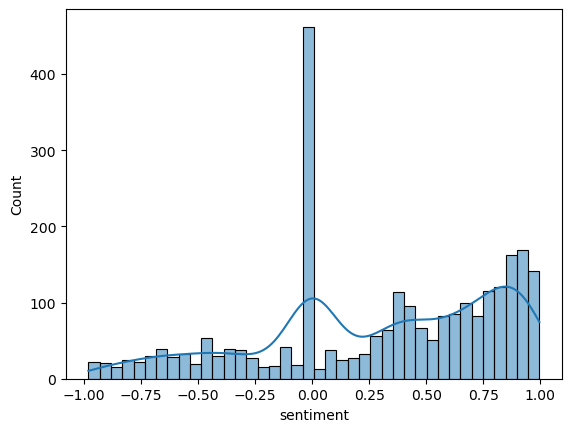

In [293]:
sns.histplot(
    comments_df["sentiment"],
    bins=40,
    kde=True
)

In [294]:
video_sentiment = (
    comments_df
    .groupby("video_id")["sentiment"]
    .mean()
    .reset_index()
)

<Axes: xlabel='sentiment', ylabel='Count'>

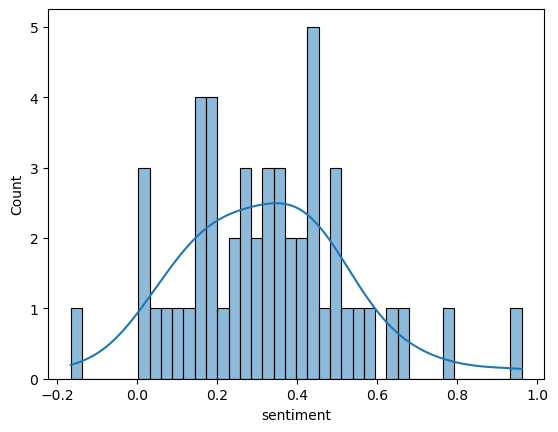

In [295]:
sns.histplot(
    video_sentiment["sentiment"],
    bins=40,
    kde=True
)

In [296]:
video_sentiment.describe()

,sentiment
count,50.000000
mean,0.322119
std,0.209772
min,-0.165579
25%,0.176203
50%,0.320049
75%,0.443541
max,0.960700


## Video Type Classification

In [297]:
def classify_video_type(title):

    title = str(title).lower()

    if any(word in title for word in ["review", "test", "unpack"]):
        return "review"

    if any(word in title for word in ["news", "reportage", "Nachrichten", "schau"]):
        return "news"

    return "other"

In [298]:
videos_df["video_type"] = (
    videos_df["title"]
    .apply(classify_video_type)
)
videos_df["video_type"]

0      other
1      other
2      other
3      other
4      other
5      other
6      other
7      other
8      other
9      other
10     other
11     other
12     other
13     other
14     other
15     other
16     other
17     other
18     other
19     other
20     other
21     other
22     other
23     other
24     other
25     other
26     other
27     other
28     other
29     other
30     other
31     other
32     other
33     other
34     other
35     other
36    review
37     other
38     other
39     other
40     other
41     other
42     other
43     other
44     other
45     other
46     other
47     other
48     other
49     other
Name: video_type, dtype: object

In [299]:
comments_df = comments_df.merge(
    videos_df[
        ["video_id", "video_type"]
    ],
    on="video_id",
    how="left"
)

<Axes: xlabel='video_type', ylabel='sentiment'>

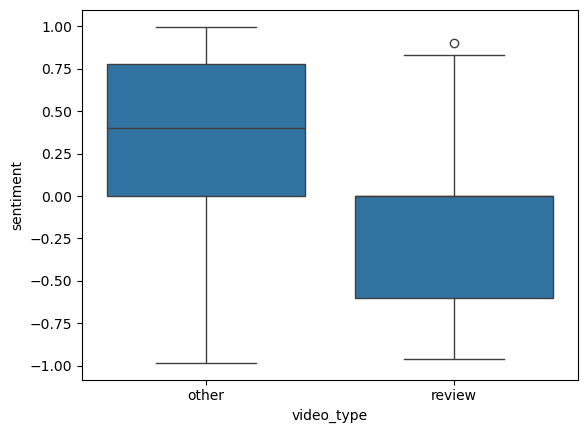

In [300]:
sns.boxplot(
    data=comments_df,
    x="video_type",
    y="sentiment"
)

## Include newly designed columns in Sqlite Database

First, if not done yet, create the new columns in sqlite. This only needs to be done once for database setup, so it should remain commented out in production.

In [301]:
# Add 'sentiment' and 'video_type' columns to 'videos' table in sqlite
# This only needs to be done once for database setup

#cursor = conn.cursor()

#cursor.execute(
#    """
#    ALTER TABLE videos
#    ADD COLUMN sentiment REAL
#    """
#)

#cursor.execute(
#    """
#    ALTER TABLE videos
#    ADD COLUMN sentiment REAL
#    """
#)

#conn.commit()

In [302]:
# Add 'sentiment' and 'video_type' columns to 'comments' table in sqlite
#cursor = conn.cursor()

#cursor.execute(
#    """
#    ALTER TABLE comments
#    ADD COLUMN sentiment REAL
#    """
#)

#cursor.execute(
#    """
#    ALTER TABLE comments
#    ADD COLUMN video_type TEXT
#    """
#)

#conn.commit()

Now, include the new content by deleting the old rows...

In [303]:
cursor = conn.cursor()

cursor.execute(
    """
    DELETE FROM comments
    WHERE query_slug = ?
    """,
    (query_slug,)
)

cursor.execute(
    """
    DELETE FROM videos
    WHERE query_slug = ?
    """,
    (query_slug,)
)

conn.commit()

... and adding the new ones:

In [304]:
comments_df.columns

Index(['comment_id', 'video_id', 'author', 'text', 'like_count',
       'published_at', 'reply_count', 'query_origin', 'query_slug', 'year',
       'month', 'calendar_week', 'weekday', 'language', 'text_length',
       'clean_text', 'sentiment', 'video_type'],
      dtype='object')

In [305]:
comments_df.to_sql(
    "comments",
    conn,
    if_exists="append",
    index=False
)

videos_df.to_sql(
    "videos",
    conn,
    if_exists="append",
    index=False
)

50

In [306]:
pd.read_sql(
    """
    PRAGMA table_info(videos)
    """,
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,video_id,TEXT,0,None,0
1,1,title,TEXT,0,None,0
2,2,description,TEXT,0,None,0
3,3,channel,TEXT,0,None,0
4,4,published_at,TEXT,0,None,0
5,5,view_count,INTEGER,0,None,0
6,6,like_count,INTEGER,0,None,0
7,7,comment_count,INTEGER,0,None,0
8,8,query_origin,TEXT,0,None,0
9,9,query_slug,TEXT,0,None,0


In [307]:
pd.read_sql(
    """
    PRAGMA table_info(video_description_embeddings)
    """,
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,video_id,TEXT,0,None,0
1,1,query_slug,TEXT,0,None,0
2,2,description_embedding_json,TEXT,0,None,0


### Close connection to sqlite:

In [308]:
conn.close()